## 1. Введение

> ✍ Из предыдущих модулей вы узнали, как получать данные, когда они хранятся в файлах разных форматов. В реальных проектах данные, как правило, не содержатся в готовом виде в каком-то файле — для анализа необходимо предварительно их собрать, например скопировав с какого-нибудь стороннего веб-сайта.

В этом модуле мы рассмотрим, как с помощью Python можно упростить сбор информации из интернета и, в некоторых случаях, получить доступ к данным, которые невозможно «собрать руками».    
В частности, мы:

* рассмотрим, в каком виде информация обычно находится в интернете;
* напишем программы, которые собирают данные с веб-сайтов, используя библиотеки **requests** и **BeautifulSoup**;
* разберёмся, что такое программный интерфейс веб-сервисов (API) и как его использовать (для примера мы будем собирать данные в социальной сети ВКонтакте).

К концу изучения модуля вы сможете писать программы, которые избавят вас от многих часов монотонной работы и расширят спектр собираемой информации.

## 2. Веб-запросы

> Процесс получения/извлечения информации с веб-ресурсов в интернете называется web-scraping (рус. веб-скрейпинг/веб-скрапинг).    
Веб-скрапинг может быть проделан вручную пользователем компьютера, однако этот термин обычно связывают с автоматизированными процессами, реализованными с помощью кода.

Какие данные можно извлечь в процессе веб-скрапинга?

* цены на товары конкурентов для оптимизации своей стратегии ценообразования;
* сообщения в социальных медиа, по которым можно отслеживать тренды в той или иной области;
* отзывы о товарах/услугах компании на различных площадках, которые можно впоследствии анализировать;
* контактные данные пользователей соцсетей или форумов для дальнейшего взаимодействия с этими пользователями;
* и т.д.

Для того чтобы веб-скрапинг был возможен, необходимо подключение компьютера, который будет задействован в этом процессе, к сети Интернет.

> *Интернет* — это глобальная информационная сеть, которая позволяет компьютерам по всему миру обмениваться информацией. Один компьютер (называемый *клиентом*) отправляет запрос в определённом формате другому компьютеру (называемому *сервером*) и получает ответ (текст, изображение, видео и т. д.).

![img](https://lms-cdn.skillfactory.ru/assets/courseware/v1/ddf059dbb42047b7830a83d38da9ba9f/asset-v1:SkillFactory+DSPR-2.0+14JULY2021+type@asset+block/Client-server-model.png)

Клиент и сервер взаимодействуют между собой, обмениваясь одиночными сообщениями (не потоком данных) посредством сетевых протоколов, которые формализуют общение между ними.    
В настоящее время повсеместно используемый протокол в интернете, позволяющий клиенту получать различные ресурсы (например, HTML-документы), — это протокол **HTTP**.

Запрос, отправляемый клиентом с использованием протокола HTTP, состоит из нескольких элементов:

* адрес, по которому идёт обращение (например, www.google.com);
* техническая информация, например метод запроса;
* дополнительные данные, например если загружается (передаётся) изображение.

> Адрес — это **URL**, *Uniform Resource Locator* (с англ. Унифицированный Указатель Ресурса).

Ответ, в свою очередь, состоит из следующих элементов:

* код статуса ответа: например, 200 (*«успешно»*), 404 («*не найден*») и т. д. (более полный список кодов статуса ответа можете посмотреть, перейдя по ссылке);
* текст в запрошенном формате (HTML, XML, JSON и т. д.) или мультимедийные файлы;
* прочая техническая информация.

### МЕТОДЫ ЗАПРОСОВ В ПРОТОКОЛЕ HTTP

Для того чтобы указать серверу на то, какое действие мы хотим произвести с ресурсом, в протоколе **HTTP** используются так называемые методы. В **HTTP** существует несколько методов, которые описывают действия с ресурсами.    
Чаще всего используются *GET* и *POST*.

**GET — ПОЛУЧЕНИЕ РЕСУРСА**

Метод *GET* запрашивает информацию из указанного источника и не может влиять на его содержимое. Запрос доступен для кэширования данных (то есть для сохранения, восстановления и дальнейшего использования) и добавления в закладки. Длина запроса ограничена (максимальная длина — 2048 символов).

Пример GET-запроса, отправляемого через адресную строку браузера:

<http://site.ru/page.php?name=dima&age=27>

**POST — СОЗДАНИЕ РЕСУРСА**

Метод *POST* используется для отправки данных, которые могут оказывать влияние на содержимое ресурса. В отличие от метода GET, запросы *POST* не могут быть кэшированы, они не остаются в истории браузера и их нельзя добавить в закладки.    
Длина запроса POST не ограничивается.

Пример POST-запроса, отправляемого через форму запроса:



In [ ]:
POST / HTTP/1.0\r\n
Host: www.site.ru\r\n
Referer: http://www.site.ru/index.html\r\n
Cookie: income=1\r\n
Content-Type: application/x-www-form-urlencoded\r\n
Content-Length: 35\r\n
\r\n
login=Dima&password=12345

**ДОПОЛНИТЕЛЬНО**

Подробнее про методы *HTTP* можете прочитать, перейдя по этой [ссылке](https://developer.mozilla.org/ru/docs/Web/HTTP/Methods).

Эти знания пригодятся нам с вами в дальнейшем при подготовке запросов на получение информации от сервера и анализе полученных от него ответов.

## 3. Библиотека requests

> ✍ В стандартной библиотеке Python для отправки веб-запросов существует функция *urllib2*, но большинство разработчиков используют стороннюю библиотеку *requests* (c англ. запросы), потому что её работа более стабильна, а созданный с её помощью код получается проще.    
Поэтому мы будем работать с библиотекой *requests*, а *urllib2* рассматривать не будем.

Познакомимся с библиотекой *requests*, решив простую задачу — получить значения курсов валют.    
Курс валют — полезная и регулярно обновляемая информация, но каждый раз в ручном режиме получать информацию о курсе интересующей валюты трудоёмко.

С помощью скрипта мы будем в удобном виде выгружать информацию по курсам валют с заранее выбранного сайта.

Один из сайтов в интернете, на котором информация о курсах валют дублирует информацию с сайта [Центрального Банка России](https://www.cbr.ru/), — ресурс [Курсы валют ЦБ РФ в XML и JSON](https://www.cbr-xml-daily.ru/).    
На данном ресурсе информация о курсах валют представлена в разных форматах, в том числе и в структурированном JSON-формате, методы работы с которым мы изучили в одном из предыдущих модулей.

Перед началом работы библиотеку requests потребуется установить.    
Например, в Jupyter Notebook это делается с помощью такой команды:

In [ ]:
# Устанавливаем библиотеку requests
!pip install requests 

Как только библиотека установлена, импортируем её и отправим наш первый запрос к ресурсу Курсы валют ЦБ РФ в XML и JSON.    
Используем метод *get()* из библиотеки *requests*, передав ему соответствующий URL —  https://www.cbr-xml-daily.ru/daily_json.js:

In [3]:
import requests # Импортируем библиотеку requests
url = 'https://www.cbr-xml-daily.ru/daily_json.js' # Определяем значение URL страницы для запроса
response = requests.get(url) # Делаем GET-запрос к ресурсу и результат ответа сохраняем в переменной response

Проверим ответ сервера — содержимое переменной response:

In [4]:
print(response) # Выводим значение response на экран как объект

<Response [200]>


Мы получили объект ответа Response, который содержит всю нужную нам информацию. По умолчанию в квадратных скобках на экран выводится код статуса ответа. В данном случае он равен 200 — то есть запрос был корректным и сервер отдал нам нужную информацию.    
Значение кода статуса 404 означало бы, что страница по указанному адресу не найдена, а значение 403 — что синтаксис GET-запроса неверный.

Код ответа в виде числовой переменной можно получить с помощью метода *status_code*:

In [5]:
print(response.status_code) # Выводим числовое значение response на экран

200


### РАБОТАЕМ С ОТВЕТОМ

Мы сделали запрос и получили корректный ответ (код статуса — 200). Дальнейшую работу производим с результатом запроса к ресурсу Курсы валют **ЦБ РФ** в **XML** и **JSON**.

Текст ответа хранится в атрибуте text. Выведем значение атрибута на экран и посмотрим на его содержимое:

In [ ]:
print(response.text) # Выводим содержимое атрибута text переменной response на экран

> Как правило, при работе над реальным проектом на этапе получения данных мы уже понимаем, с какими форматами данных нам придётся работать.    
На предлагаемом для работы ресурсе информация есть как в *JSON*-формате, так и в *XML*. По нашему запросу ресурс возвращает информацию в *JSON*-формате, однако в настоящий момент результат хранится как единая строка.    
Проверить тип данных полученного ответа можно, воспользовавшись функцией *type*().

Для того чтобы удобно было работать с полученной информацией, нам необходимо преобразовать строку в словарь.    
В объект ответа Response  из библиотеки *requests* уже встроен метод *json*() .

Импортируем функцию *pprint*(), применим к полученному ответу метод *json*() и выведем полученный результат на экран:

In [7]:
from pprint import pprint # Импортируем функцию pprint()
import json # Импортируем модуль json
currencies = response.json() # Применяем метод json()
pprint(currencies) # Выводим результат на экран

{'Date': '2024-08-17T11:30:00+03:00',
 'PreviousDate': '2024-08-16T11:30:00+03:00',
 'PreviousURL': '//www.cbr-xml-daily.ru/archive/2024/08/16/daily_json.js',
 'Timestamp': '2024-08-17T20:00:00+03:00',
 'Valute': {'AED': {'CharCode': 'AED',
                    'ID': 'R01230',
                    'Name': 'Дирхам ОАЭ',
                    'Nominal': 1,
                    'NumCode': '784',
                    'Previous': 24.1786,
                    'Value': 24.2086},
            'AMD': {'CharCode': 'AMD',
                    'ID': 'R01060',
                    'Name': 'Армянских драмов',
                    'Nominal': 100,
                    'NumCode': '051',
                    'Previous': 22.8702,
                    'Value': 22.9069},
            'AUD': {'CharCode': 'AUD',
                    'ID': 'R01010',
                    'Name': 'Австралийский доллар',
                    'Nominal': 1,
                    'NumCode': '036',
                    'Previous': 58.783,
             

Теперь данные находятся в словаре и можно легко получать необходимые значения.

Например, по ключу Valute мы можем обратиться к вложенному словарю, который содержит информацию о мировых валютах.   
Выведем на экран, например, информацию о евро (*EUR*):

In [9]:
pprint(currencies['Valute']['EUR']) # Выводим на экран информацию о валюте евро

{'CharCode': 'EUR',
 'ID': 'R01239',
 'Name': 'Евро',
 'Nominal': 1,
 'NumCode': '978',
 'Previous': 98.3232,
 'Value': 97.839}


## 4. Парсинг сайтов

> ✍ Ресурс, с которым мы работали в предыдущем юните, возвращал ответ о текущем курсе валют в удобном, структурированном формате, из которого было легко извлечь необходимую информацию.    
Довольно часто для получения информации приходится обращаться напрямую к HTML-страницам.

Для примера рассмотрим [страницу](https://nplus1.ru/news/2021/10/11/econobel2021), содержащую статью с информацией о присуждении Нобелевской премии по экономике в 2021 году, и попробуем извлечь из неё заголовок статьи, опубликованной на странице, дату публикации, а также текст статьи.

Получить содержимое страницы в большинстве случаев несложно, гораздо труднее извлечь из HTML-кода нужную информацию.

### ОСНОВЫ HTML

> **HTML** (англ. *HyperText Markup Language*, рус. язык гипертекстовой разметки) — стандартизированный язык разметки документов в интернете. Большинство веб-страниц содержат описание разметки на языке HTML.    
Язык HTML интерпретируется браузерами. Полученный в результате интерпретации текст отображается на экране монитора компьютера или мобильного устройства.

*HTML* позволяет создавать макет страницы, разбивая её на блоки: мы можем поместить содержимое посередине страницы, сбоку и т. п.

Кроме того, *HTML* используется для описания форматирования. Например, с его помощью мы можем указать, какая часть текста должна отображаться крупным шрифтом как заголовок, какая — курсивом, а какая — как обычный текст.

*HTML* является близким родственником уже знакомого вам формата XML. Разметка на языке *HTML* делается с помощью так называемых тегов, которые помещаются в угловые скобки, и применяется к элементам, заключённым внутри них.    
Посмотрите на примеры:


In [ ]:
<h2> Это заголовок второго уровня </h2>
<div> А это обычный текст </div>

У корректной HTML-страницы есть заголовок и тело страницы. В заголовке (в тегах *head* … */head*)  размещается техническая информация, подключаются скрипты и стили.    
В теле *body* … */body* находятся текст и данные, которые непосредственно отображаются на странице в браузере.

Разметка небольшой страницы выглядит примерно так:

In [ ]:
<!DOCTYPE html>
<html lang="ru">
    <head>
        <title>Название страницы</title>
        <meta charset="UTF-8">
    </head>
    <body>
        <h1> Это заголовок страницы </h1>
        <p> Какой-то текст </p>
    </body>
</html>

Обратите внимание, что теги образуют иерархическую структуру, то есть одни теги расположены внутри других.    
В примере выше тег *p* … */p* находится внутри тега *body* … */body*.

Кроме того, у тегов могут быть атрибуты, которые пишутся внутри открывающегося тега. Самые популярные атрибуты — это *class* и *id*:

In [ ]:
<h1 id="big-title"> Заголовок страницы </h1>
<p class="red-back"> Какой-то текст </p>

Изучение языка HTML находится вне рамок этого курса, но для того, чтобы собирать информацию с веб-страниц, нет необходимости хорошо знать HTML.    
Достаточно понимать, что:

* существуют теги с разными именами;
* у тегов бывают атрибуты, такие как class и id;
* теги образуют иерархическую структуру, то есть одни теги вложены в другие.


> **ДОПОЛНИТЕЛЬНО**

Вы можете ознакомиться с информацией о HTML в справочнике, перейдя по [ссылке](http://htmlbook.ru/html)

### ПОЛУЧАЕМ СОДЕРЖИМОЕ ВЕБ-СТРАНИЦЫ

Получим HTML-код интересующей нас страницы.

Для этого отправим GET-запрос с помощью библиотеки requests и метода *get()* и посмотрим на текст ответа на наш запрос (как мы помним, он содержится в атрибуте text):

In [13]:
import requests # Импортируем библиотеку requests
url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url)  # Выполняем GET-запрос
print(response.text)  # Выводим содержимое атрибута text

<!DOCTYPE html>
<html prefix="og: http://ogp.me/ns#" lang="ru">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей</title>
    <link rel="preload" href="https://staticn1.nplus1.ru/fonts/AeonikPro/AeonikPro-Regular.woff2" as="font" type="font/woff2" crossorigin />
    <link rel="preload" href="https://staticn1.nplus1.ru/fonts/Spectral/Spectral-Regular.woff" as="font" type="font/woff2" crossorigin />
  <link href="/front-build/css/main.css?id=842e64708435127ee441c2e86afffea2" rel="stylesheet">
  <link href="/front-build/css/app.css?id=92673ebe7185ebc42e29fc7294a4c65f" rel="stylesheet">
  

  <link rel="apple-touch-icon" sizes="180x180" href="/apple-touch-icon.png">
  <link rel="icon" type="image/png" sizes="32x32" href="/favicon-32x32.png">
  <link rel="icon" type="image/png" sizes="16x16" href="/favicon-16x16.png">
  <link rel="

> В отличие от предыдущего примера, где ответ возвращался в JSON-формате, мы не можем так просто преобразовать HTML-код в словарь и извлечь необходимую нам информацию.

Для решения таких задач в Python существует специальная библиотека ***BeautifulSoup***, о работе с которой мы поговорим в следующем юните.

## 5. Библиотека BeautifulSoup

> ✍ Для поиска необходимых нам данных мы будем использовать библиотеку BeautifulSoup, которая позволяет по названию тегов и их атрибутов получать содержащийся в них текст.

*BeautifulSoup* не является частью стандартной библиотеки, поэтому для начала её нужно установить. Например, в Jupyter Notebook это делается с помощью такой команды:

In [14]:
# Устанавливаем библиотеку BeautifulSoup
!pip install beautifulsoup4 

   ---------------------------------------- 0.0/147.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/147.9 kB ? eta -:--:--
   -- ------------------------------------- 10.2/147.9 kB ? eta -:--:--
   ---------- ---------------------------- 41.0/147.9 kB 393.8 kB/s eta 0:00:01
   ------------------------------- ------ 122.9/147.9 kB 901.1 kB/s eta 0:00:01
   -------------------------------------- 147.9/147.9 kB 976.5 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


После установки импортируем библиотеку в наш код:

In [15]:
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup

Теперь мы можем извлекать данные из любой веб-страницы.

Ранее мы уже получили содержимое страницы с помощью *GET*-запроса и сохранили информацию в переменной *response* , теперь создадим объект *BeautifulSoup* с именем page, указывая в качестве параметра *html.parser*.

Для примера получим информацию o *title* (с англ. заголовок) — это строка, которая отображается на вкладке браузера:

In [16]:
import requests # Импортируем библиотеку requests
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup
url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер
print(page.title) # Получаем тег title, отображающийся на вкладке браузера
print(page.title.text) # Выводим текст из полученного тега, который содержится в атрибуте text

<title>Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей</title>
Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей


> Если при запросе к сайту, а затем при его разборе с помощью *BeautifulSoup* в тексте страницы не находится нужный тег, попробуйте вывести на печать пару тысяч символов текста страницы.    
Если там обнаружится нечто похожее на капчу, возможно, сайт посчитал вас роботом и отказывается выдавать содержимое. Чтобы получить его, попробуйте «притвориться» браузером при запросе из скрипта:

<requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})>   
*User-Agent* своего браузера можно узнать по этой [ссылке](https://whatmyuseragent.com/).

### ИЗВЛЕКАЕМ ЗАГОЛОВОК СТАТЬИ

Выполним поставленную ранее задачу: получить информацию о странице и извлечь заголовок [статьи](https://nplus1.ru/news/2021/10/11/econobel2021), опубликованной на этой странице, дату публикации, а также текст статьи.

Предположим, что мы знаем, что в *HTML*-коде рассматриваемой нами страницы заголовок статьи заключён в тег *h1* … */h1* (заголовок первого уровня).

Тогда мы можем получить его текст с помощью метода *find()* (с англ. найти) объекта *BeautifulSoup*, передав ему название интересующего нас тега:

In [17]:
# Применяем метод find() к объекту и выводим результат на экран
print(page.find('h1').text) 


            Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей
          


> ? Но как же узнать, в каких именно тегах заключена необходимая информация?

Проще всего это сделать с помощью так называемого инструмента разработчика, который есть во всех современных браузерах. Покажем, как открыть данный инструмент на примере использования браузера Google Chrome.

Устанавливаем курсор на элементе страницы (заголовок статьи), информацию о котором хотим получить, нажимаем на правую клавишу мыши и в выпадающем списке выбираем пункт **«Просмотреть код элемента»** или **«Исследовать»** в зависимости от браузера.

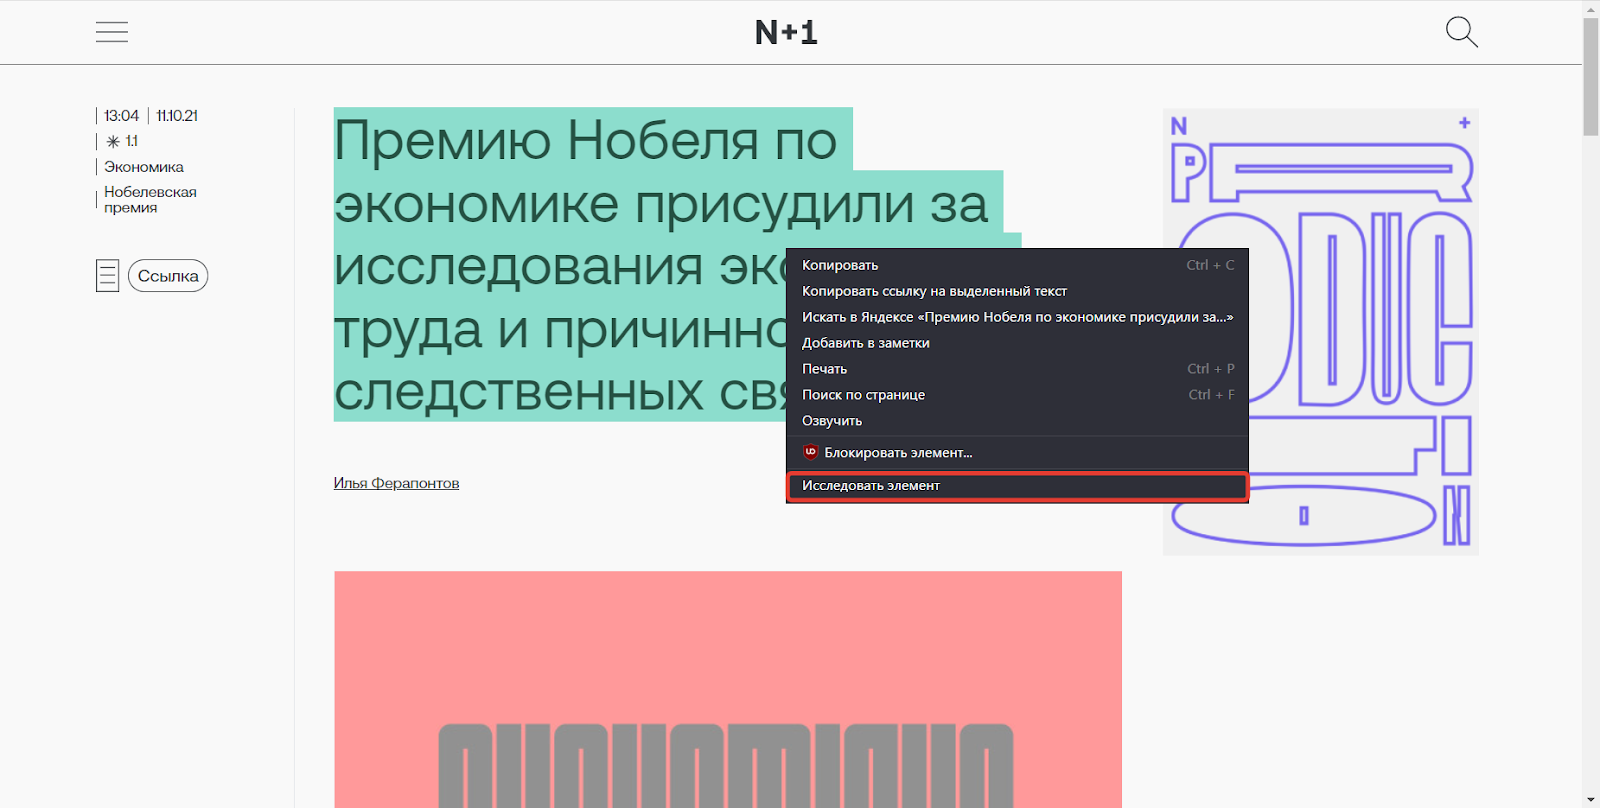

В открывшемся окне инструмента разработчика видим, что информация о заголовке статьи заключена в теге *h1* ... */h1*.

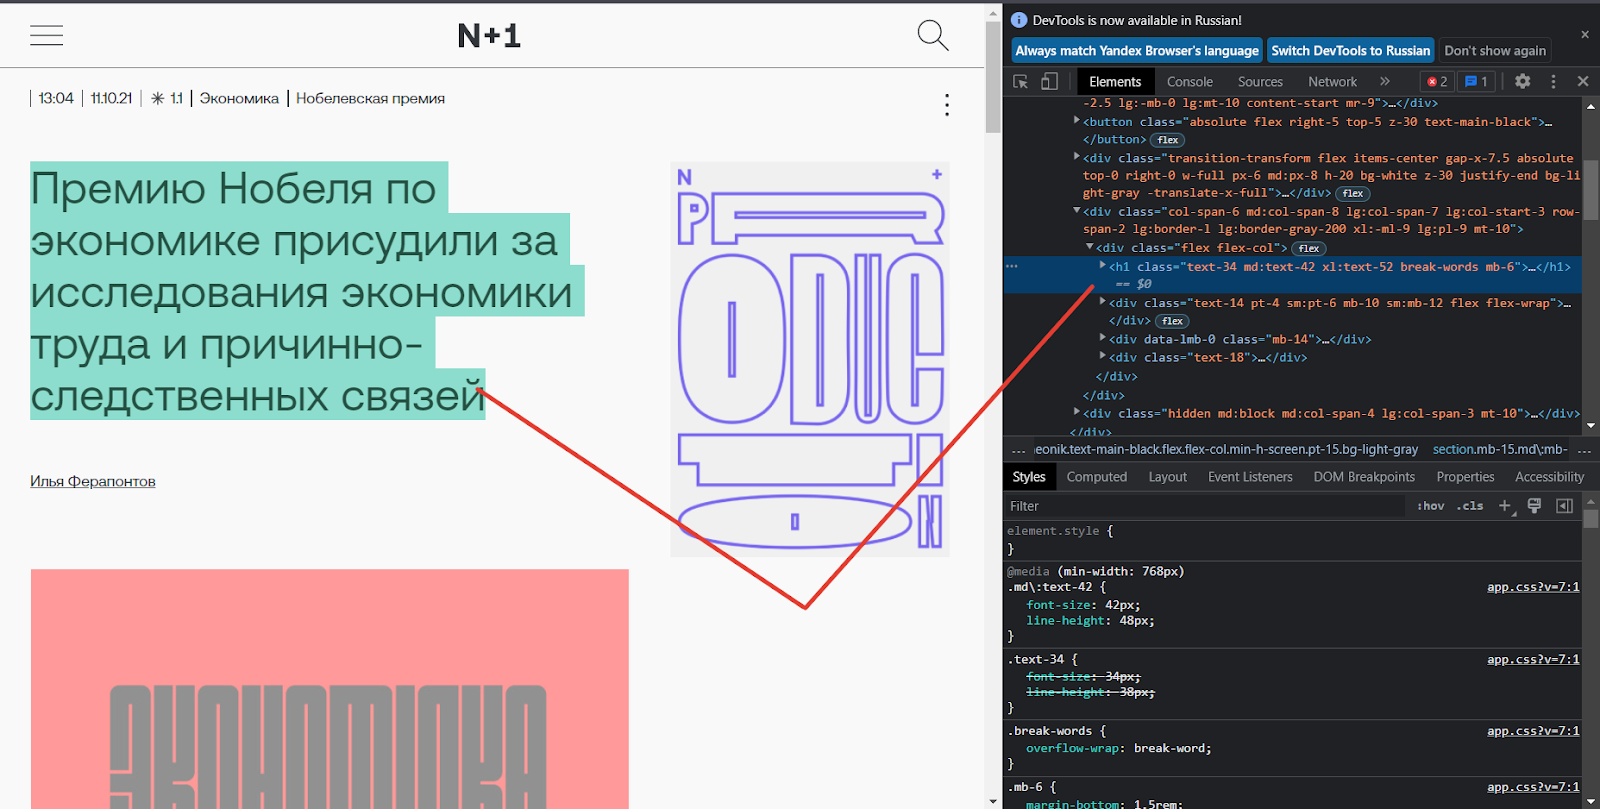



### Задание 5.4 (External resource)



Напишите функцию *wiki_header*, которая по адресу страницы возвращает заголовок первого уровня для статей на *Wikipedia*.

Функция *wiki_header* принимает один аргумент - *url*.

> wiki_header('https://en.wikipedia.org/wiki/Operating_system')
'Operating system'

In [22]:
import requests # Импортируем библиотеку requests
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup

def wiki_header(url):
    response = requests.get(url) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
    page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер
    return (page.find('h1').text)

    
print(wiki_header('https://en.wikipedia.org/wiki/Operating_system'))

Operating system
